# IMPORT LIBRARIES

In [ ]:
from stumpy import stump, motifs


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# LOAD DATA

In [2]:
X_paa = np.load("arrays/X_paa.npy")

In [3]:
df_detrended_full = pd.read_csv("dataset/time_series_post.csv")

In [4]:
df_detrended_full.columns

Index(['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '90', '91', '92', '93', '94', '95', '96', '97', '98', '99'],
      dtype='object', length=101)

In [5]:
df = pd.read_csv("dataset/imdb_ts.csv")

# MOTIFS & DISCORDS

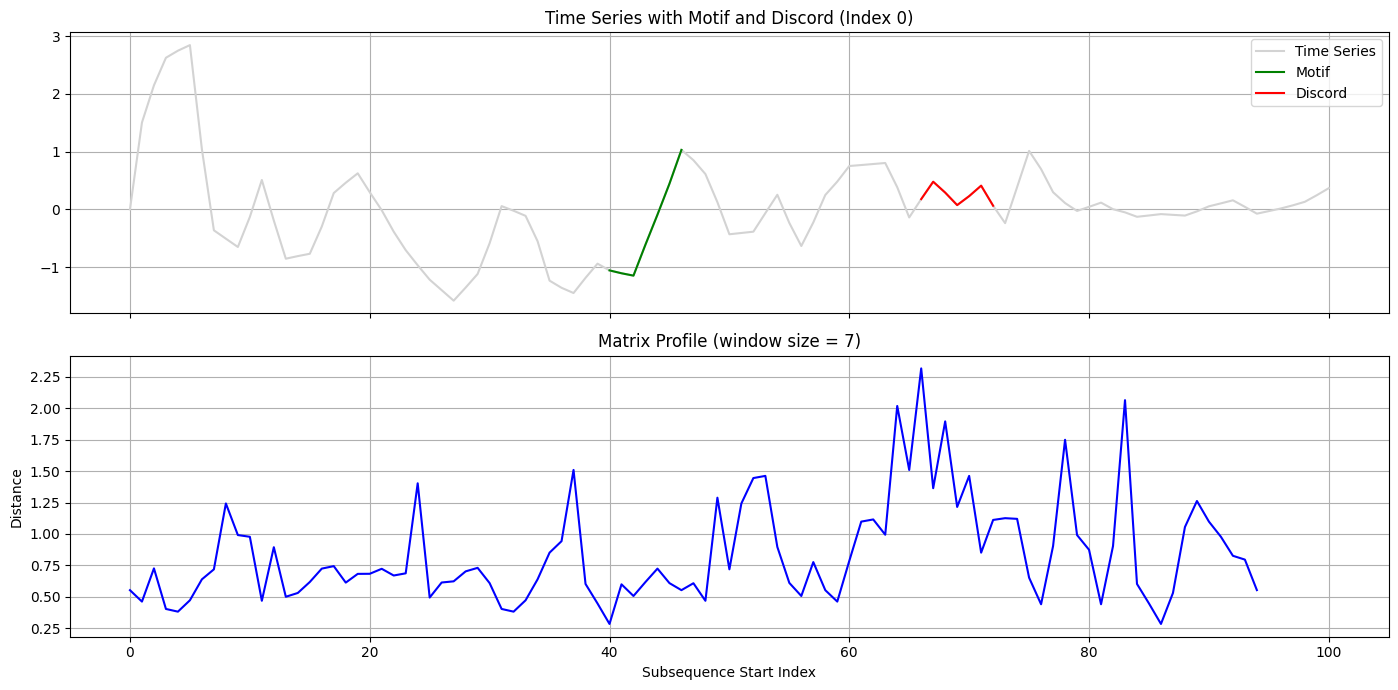

In [36]:
# Select a time series (e.g. index 0)
ts = df_detrended_full.iloc[0].to_numpy()

# Choose window size (number of consecutive points in a subsequence)
m = 7  # adjust as needed

# Compute Matrix Profile using STUMP
mp = stump(ts, m)

# mp[:, 0] contains the matrix profile values (distances)
matrix_profile = mp[:, 0]

# Find the index of the motif and discord
motif_idx = np.argmin(matrix_profile)
discord_idx = np.argmax(matrix_profile)

# Plot
fig, axs = plt.subplots(2, figsize=(14, 7), sharex=True)

# Time series with highlighted motif and discord
axs[0].plot(ts, color="lightgray", label="Time Series")
axs[0].plot(
    np.arange(motif_idx, motif_idx + m),
    ts[motif_idx : motif_idx + m],
    color="green",
    label="Motif",
)
axs[0].plot(
    np.arange(discord_idx, discord_idx + m),
    ts[discord_idx : discord_idx + m],
    color="red",
    label="Discord",
)
axs[0].set_title("Time Series with Motif and Discord (Index 0)")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(matrix_profile, color="blue")
axs[1].set_title("Matrix Profile (window size = {})".format(m))
axs[1].set_xlabel("Subsequence Start Index")
axs[1].set_ylabel("Distance")
axs[1].grid(True)

plt.tight_layout()
plt.show()


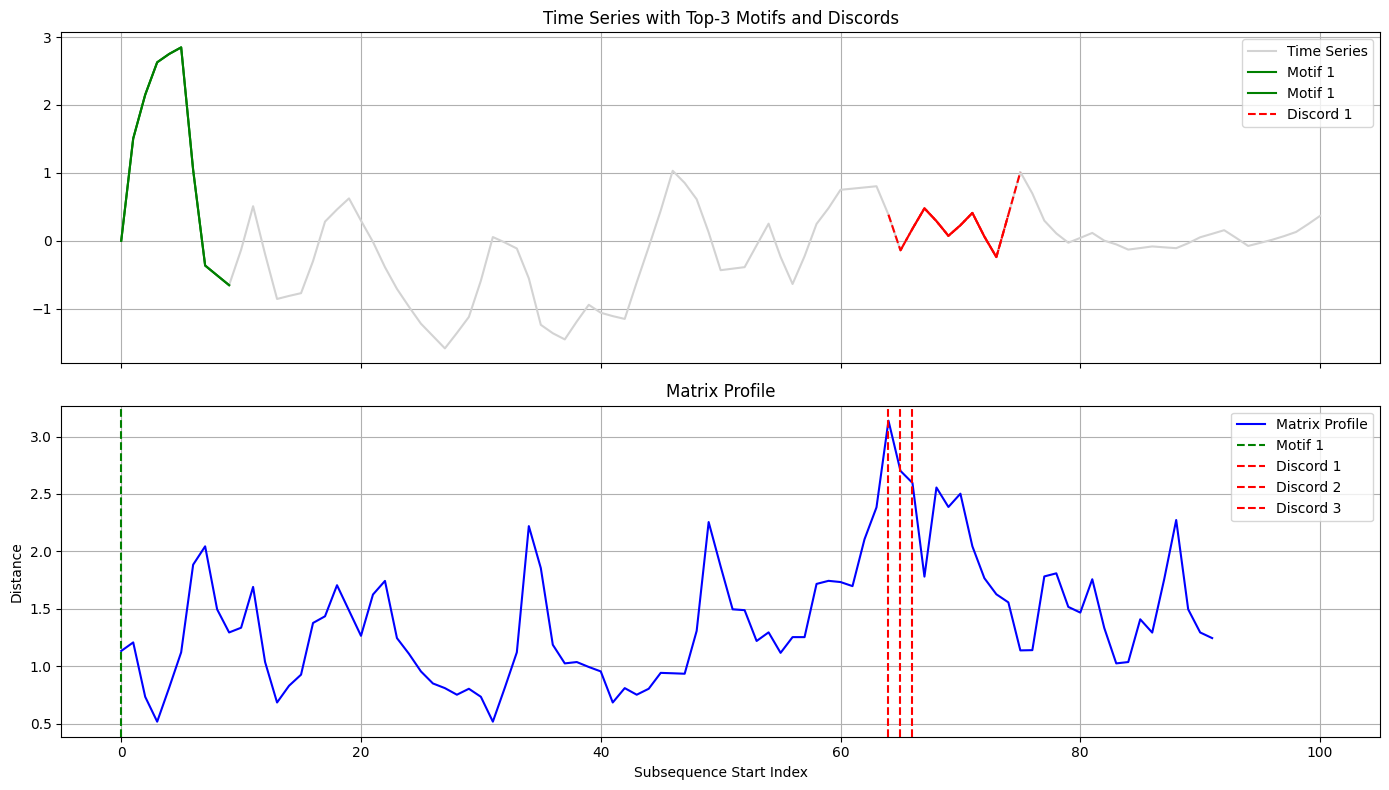

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stumpy import stump, motifs

# Load your time series (e.g. movie 0)
ts = df_detrended_full.iloc[0].to_numpy()
m = 10  # subsequence window size

# Compute Matrix Profile
mp = stump(ts, m)
mp_values = mp[:, 0]

# Get top-3 motif sets (each is a list of similar indices)
motif_sets, _ = motifs(ts, mp_values, max_motifs=3)


# Get top-3 discord indices (anomalous subsequences)
def get_top_k_discords(mp_vals, k=3):
    return [int(i) for i in np.argsort(mp_vals)[-k:][::-1]]


discord_indices = get_top_k_discords(mp_values, k=3)

# Plotting
fig, axs = plt.subplots(2, figsize=(14, 8), sharex=True)
axs[0].plot(ts, color="lightgray", label="Time Series")

colors = ["green", "orange", "purple"]

# Plot motifs
for i, motif_set in enumerate(motif_sets):
    for idx in motif_set:
        idx = int(idx)
        axs[0].plot(
            np.arange(idx, idx + m),
            ts[idx : idx + m],
            color=colors[i],
            label=f"Motif {i + 1}" if idx == int(motif_set[0]) else None,
        )

# Plot discords
for i, idx in enumerate(discord_indices):
    idx = int(idx)
    axs[0].plot(
        np.arange(idx, idx + m),
        ts[idx : idx + m],
        color="red",
        linestyle="--",
        label=f"Discord {i + 1}" if i == 0 else None,
    )

axs[0].legend()
axs[0].set_title("Time Series with Top-3 Motifs and Discords")
axs[0].grid(True)

# Matrix Profile
axs[1].plot(mp_values, color="blue", label="Matrix Profile")
for i, motif_set in enumerate(motif_sets):
    axs[1].axvline(
        int(motif_set[0]), color=colors[i], linestyle="--", label=f"Motif {i + 1}"
    )
for i, idx in enumerate(discord_indices):
    axs[1].axvline(idx, color="red", linestyle="--", label=f"Discord {i + 1}")
axs[1].legend()
axs[1].set_title("Matrix Profile")
axs[1].set_xlabel("Subsequence Start Index")
axs[1].set_ylabel("Distance")
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [6]:
df_merged = pd.concat(
    [df.reset_index(drop=True), df_detrended_full.reset_index(drop=True)], axis=1
)


In [7]:
df_merged = df_merged.drop(columns=["Unnamed: 0"])

In [8]:
df_detrended_full = df_detrended_full.drop(columns=["Unnamed: 0"])

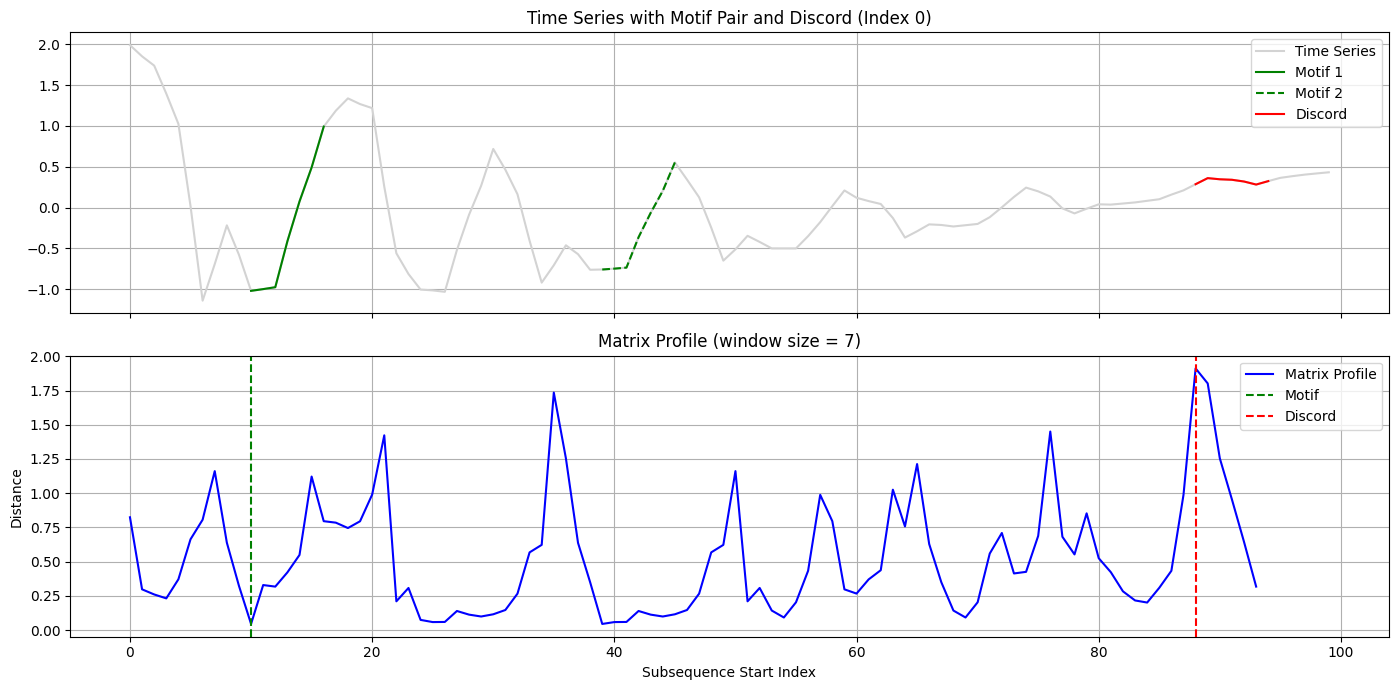

In [45]:
ts = df_detrended_full.iloc[1067].to_numpy()
m = 7
mp = stump(ts, m)

motif_idx_1 = np.argmin(mp[:, 0])
motif_idx_2 = int(mp[motif_idx_1, 1])  # indice del match più vicino

discord_idx = np.argmax(mp[:, 0])

fig, axs = plt.subplots(2, figsize=(14, 7), sharex=True)

axs[0].plot(ts, color="lightgray", label="Time Series")
axs[0].plot(
    np.arange(motif_idx_1, motif_idx_1 + m),
    ts[motif_idx_1 : motif_idx_1 + m],
    color="green",
    label="Motif 1",
)
axs[0].plot(
    np.arange(motif_idx_2, motif_idx_2 + m),
    ts[motif_idx_2 : motif_idx_2 + m],
    color="green",
    linestyle="--",
    label="Motif 2",
)
axs[0].plot(
    np.arange(discord_idx, discord_idx + m),
    ts[discord_idx : discord_idx + m],
    color="red",
    label="Discord",
)
axs[0].set_title("Time Series with Motif Pair and Discord (Index 0)")
axs[0].legend()
axs[0].grid(True)

# Matrix Profile
axs[1].plot(mp[:, 0], color="blue", label="Matrix Profile")
axs[1].axvline(motif_idx_1, color="green", linestyle="--", label="Motif")
axs[1].axvline(discord_idx, color="red", linestyle="--", label="Discord")
axs[1].legend()
axs[1].set_title(f"Matrix Profile (window size = {m})")
axs[1].set_xlabel("Subsequence Start Index")
axs[1].set_ylabel("Distance")
axs[1].grid(True)

plt.tight_layout()
plt.show()


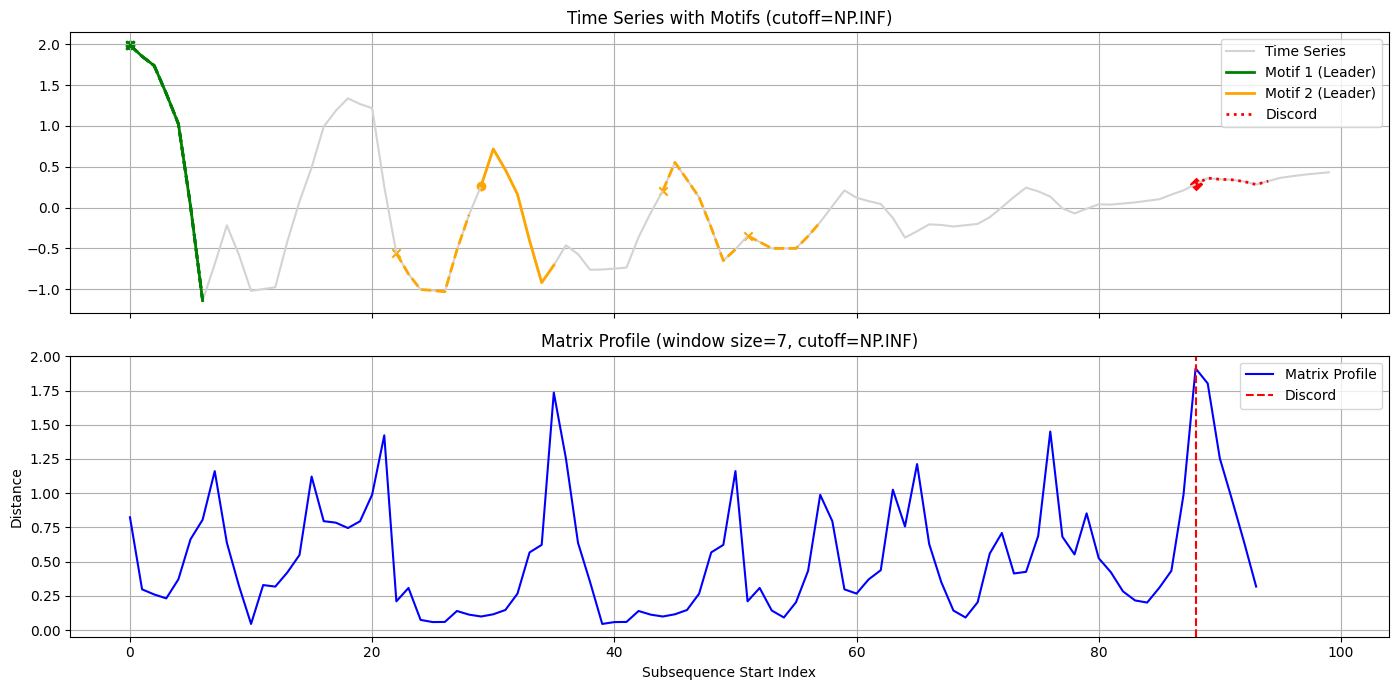

In [ ]:
from stumpy import motifs, stump
import numpy as np
import matplotlib.pyplot as plt

# Time series
ts = df_detrended_full.iloc[1067].to_numpy()
m = 7

# Matrix profile
mp = stump(ts, m)

# ---- Find top-3 motifs ----
motif_results = motifs(
    ts, mp[:, 0], max_motifs=2, max_matches=2, min_neighbors=1, cutoff=0.8
)

# ---- Find discord (highest distance) ----
discord_idx = np.argmax(mp[:, 0])

# ---- Plot ----
fig, axs = plt.subplots(2, figsize=(14, 7), sharex=True)

# Time series
axs[0].plot(ts, color="lightgray", label="Time Series")
colors = ["green", "orange", "purple"]

for i, motif_group in enumerate(motif_results):
    for j, idx in enumerate(np.ravel(motif_group)):
        if not np.isnan(idx):
            idx = int(idx)
            if j == 0:
                # Leader: solid line + circle marker
                axs[0].plot(
                    np.arange(idx, idx + m),
                    ts[idx : idx + m],
                    color=colors[i % len(colors)],
                    linewidth=2,
                    label=f"Motif {i + 1} (Leader)",
                )
                axs[0].scatter(idx, ts[idx], color=colors[i % len(colors)], marker="o")
            else:
                # Matches: dashed line + x marker
                axs[0].plot(
                    np.arange(idx, idx + m),
                    ts[idx : idx + m],
                    color=colors[i % len(colors)],
                    linewidth=2,
                    linestyle="--",
                )
                axs[0].scatter(idx, ts[idx], color=colors[i % len(colors)], marker="x")

# Discord
axs[0].plot(
    np.arange(discord_idx, discord_idx + m),
    ts[discord_idx : discord_idx + m],
    color="red",
    linestyle=":",
    linewidth=2,
    label="Discord",
)
axs[0].scatter(discord_idx, ts[discord_idx], color="red", marker="D")
axs[0].set_title(f"Time Series with Motifs")
axs[0].legend()
axs[0].grid(True)

# Matrix Profile
axs[1].plot(mp[:, 0], color="blue", label="Matrix Profile")
axs[1].axvline(discord_idx, color="red", linestyle="--", label="Discord")
axs[1].legend()
axs[1].set_title(f"Matrix Profile (window size={m}, cutoff=NP.INF)")
axs[1].set_xlabel("Subsequence Start Index")
axs[1].set_ylabel("Distance")
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
for i, motif_group in enumerate(motif_results):
    print(f"Motif {i + 1} indices:", motif_group)


Motif 1 indices: [[0.         0.09971806]
 [0.         0.21061957]
 [0.         0.23209995]]
Motif 2 indices: [[29 44]
 [22 51]
 [ 3 46]]


/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_51724/3216542235.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


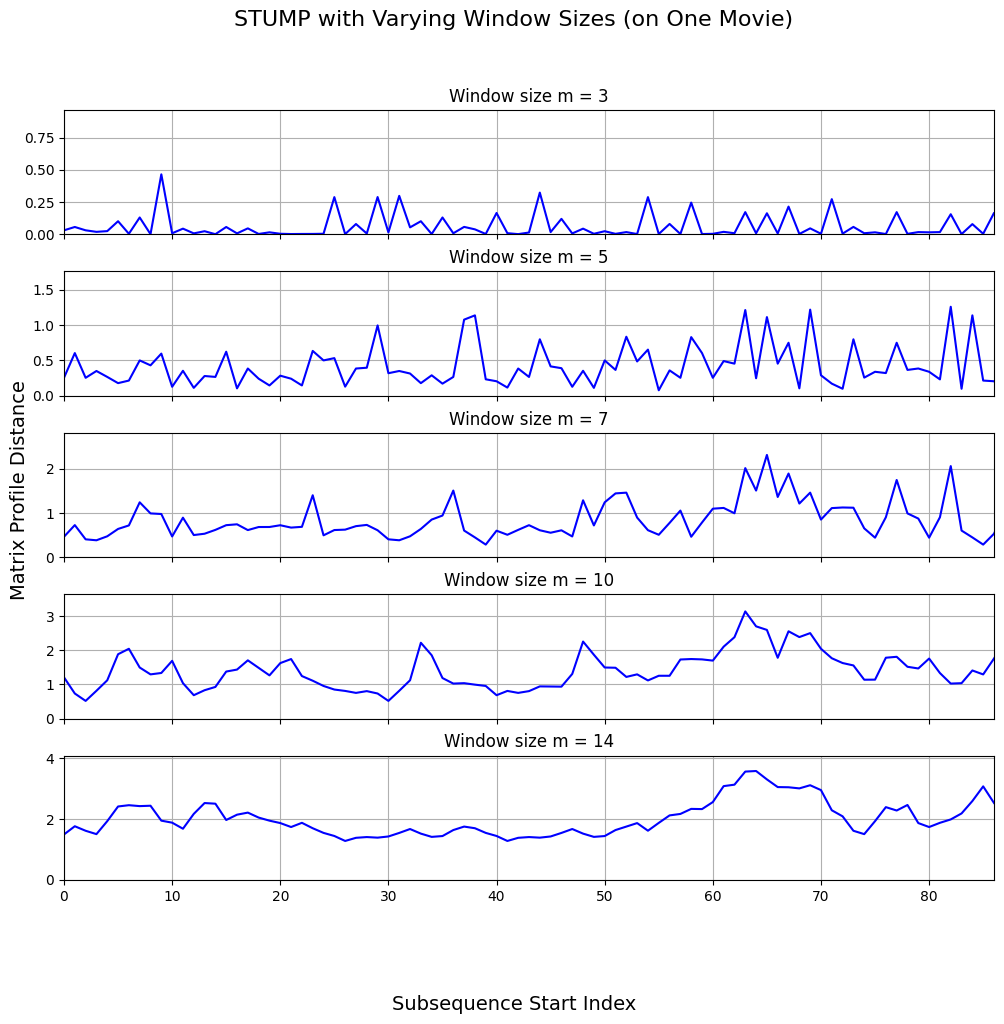

In [41]:
days_dict = {
    "3-Days": 3,
    "5-Days": 5,
    "7-Days": 7,
    "10-Days": 10,
    "14-Days": 14,
}

days_df = pd.DataFrame.from_dict(days_dict, orient="index", columns=["m"])

ts = df_detrended_full.iloc[0].to_numpy()

fig, axs = plt.subplots(
    len(days_df), figsize=(12, 10), sharex=True, gridspec_kw={"hspace": 0.3}
)
fig.text(0.5, -0.02, "Subsequence Start Index", ha="center", fontsize=14)
fig.text(
    0.08, 0.5, "Matrix Profile Distance", va="center", rotation="vertical", fontsize=14
)

for i, m in enumerate(days_df["m"].values):
    if m >= len(ts):
        continue
    mp = stump(ts, m)
    profile = mp[:, 0].astype(float)

    if np.all(np.isnan(profile)):
        axs[i].set_title(f"Window size m = {m} (all NaNs)", fontsize=12)
        axs[i].plot([], [])
        continue

    axs[i].plot(profile, color="blue")
    axs[i].set_ylim(0, np.nanmax(profile) + 0.5)
    axs[i].set_xlim(0, len(ts) - m)
    axs[i].set_title(f"Window size m = {m}", fontsize=12)
    axs[i].grid(True)

plt.suptitle("STUMP with Varying Window Sizes (on One Movie)", fontsize=16)
plt.tight_layout()
plt.show()


In [42]:
centroids = [1067, 1054, 794, 950]

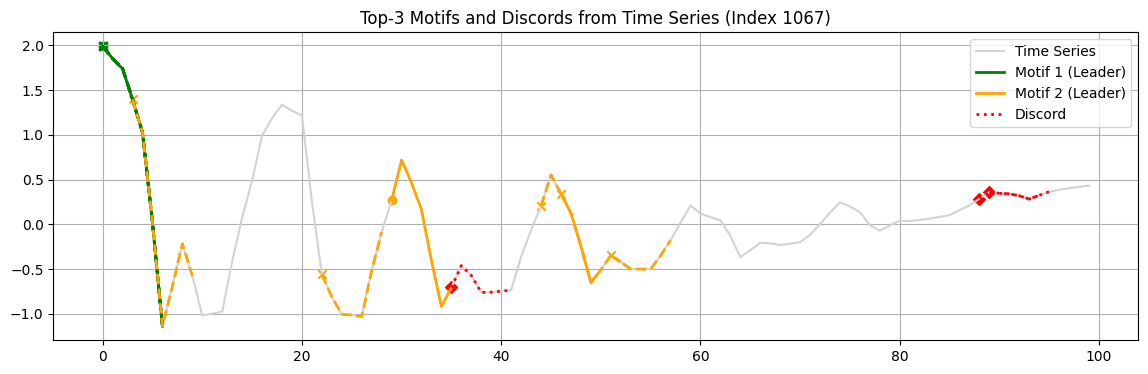

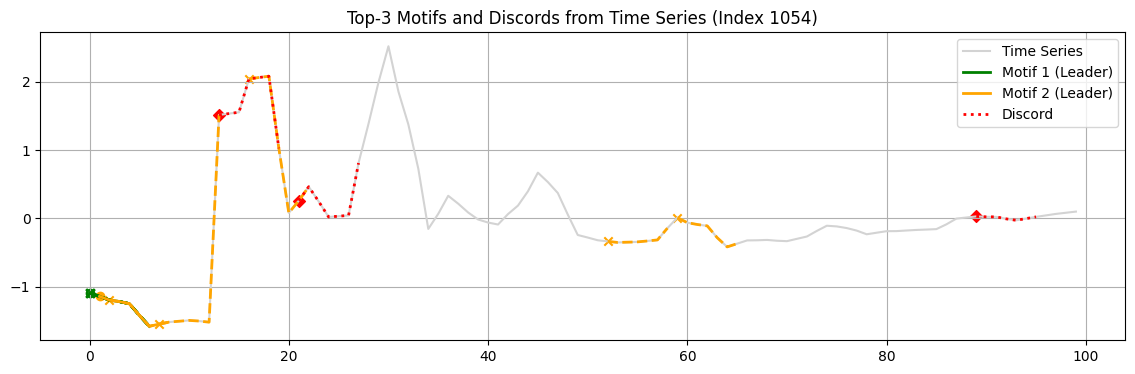

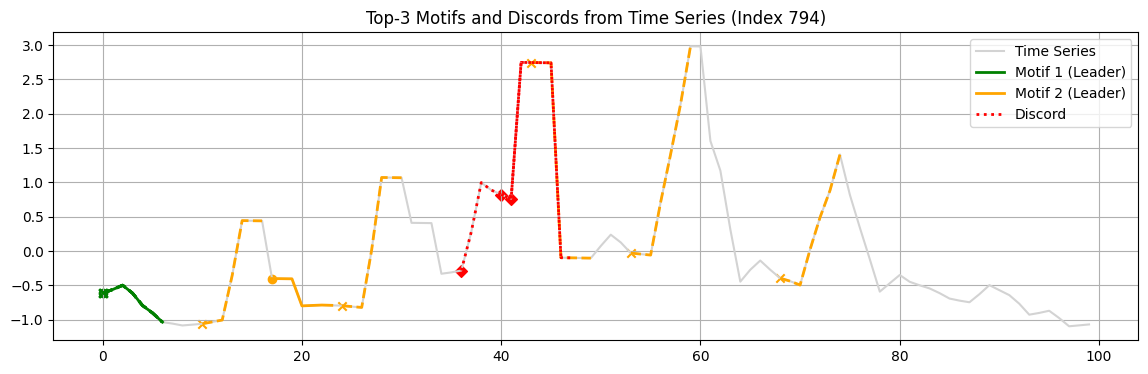

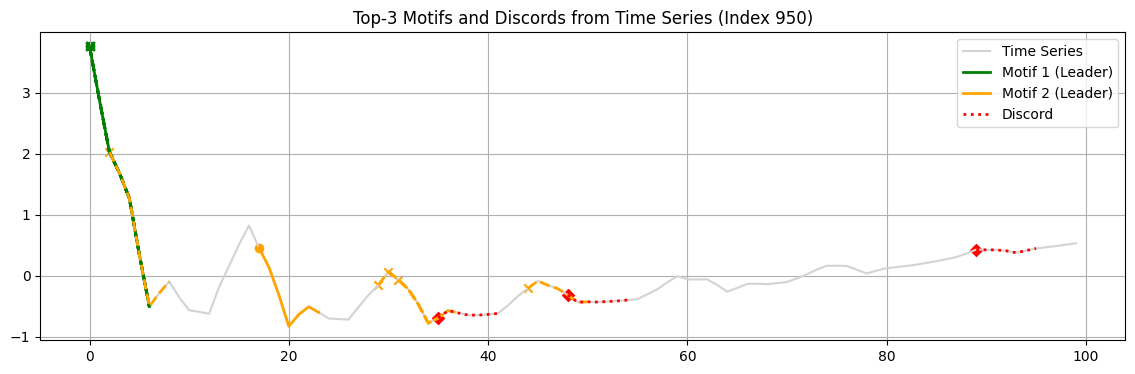

In [55]:
for c in centroids:
    ts = df_detrended_full.iloc[c].to_numpy()
    m = 7  # subsequence length

    mp = stump(ts, m)
    P = mp[:, 0]

    # Top-3 motifs (adjust cutoff if needed)
    motif_results = motifs(
        ts, P, max_motifs=3, max_matches=2, min_neighbors=1, cutoff=np.inf
    )

    # Top-3 discords = indices with highest distances in P, excluding NaN
    P_clean = np.nan_to_num(P, nan=-np.inf)
    discord_indices = np.argsort(P_clean)[-3:]

    # --- Plot ---
    colors = ["green", "orange", "purple"]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(ts, color="lightgray", label="Time Series")

    # Plot motifs (leaders vs matches)
    for i, motif_group in enumerate(motif_results):
        for j, idx in enumerate(np.ravel(motif_group)):
            if not np.isnan(idx):
                idx = int(idx)
                if j == 0:  # Leader
                    ax.plot(
                        np.arange(idx, idx + m),
                        ts[idx : idx + m],
                        color=colors[i % len(colors)],
                        linewidth=2,
                        linestyle="-",
                        label=f"Motif {i + 1} (Leader)",
                    )
                    ax.scatter(idx, ts[idx], color=colors[i % len(colors)], marker="o")
                else:  # Matches
                    ax.plot(
                        np.arange(idx, idx + m),
                        ts[idx : idx + m],
                        color=colors[i % len(colors)],
                        linewidth=2,
                        linestyle="--",
                    )
                    ax.scatter(idx, ts[idx], color=colors[i % len(colors)], marker="x")

    # Plot discords
    for i, idx in enumerate(discord_indices):
        ax.plot(
            np.arange(idx, idx + m),
            ts[idx : idx + m],
            color="red",
            linestyle=":",
            linewidth=2,
            label="Discord" if i == 0 else None,
        )
        ax.scatter(idx, ts[idx], color="red", marker="D")

    ax.set_title(f"Top-3 Motifs and Discords from Time Series (Index {c})")
    ax.legend()
    ax.grid(True)
    plt.show()


In [53]:
for c in centroids:
    ts = df_detrended_full.iloc[c].to_numpy()
    m = 7  # subsequence length

    mp = stump(ts, m)
    P = mp[:, 0]

    # Top-3 motifs
    motif_results = motifs(
        ts, P, max_motifs=3, max_matches=2, min_neighbors=1, cutoff=np.inf
    )

    # Top-3 discords = indices with highest distances in P, excluding NaN
    P_clean = np.nan_to_num(P, nan=-np.inf)
    discord_indices = np.argsort(P_clean)[-3:]

    # Plot
    colors = ["green", "orange", "purple"]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(ts, color="lightgray", label="Time Series")

    # Plot motifs
    for i, motif_group in enumerate(motif_results):
        for j, idx in enumerate(np.ravel(motif_group)):
            if not np.isnan(idx):
                idx = int(idx)
                ax.plot(
                    np.arange(idx, idx + m),
                    ts[idx : idx + m],
                    color=colors[i % len(colors)],
                    linewidth=2,
                    linestyle="--" if j > 0 else "-",
                    label=f"Motif {i + 1}" if j == 0 else None,
                )

    # Plot discords
    for i, idx in enumerate(discord_indices):
        ax.plot(
            np.arange(idx, idx + m),
            ts[idx : idx + m],
            color="red",
            linestyle=":",
            linewidth=2,
            label="Discord" if i == 0 else None,
        )

    ax.set_title(f"Top-3 Motifs and Discords from Time Series (Index {c})")
    ax.legend()
    ax.grid(True)
    plt.show()


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [44]:
motif_results

(array([[0.        , 0.22199021],
        [0.        , 0.23816761],
        [0.        , 0.2602225 ]]),
 array([[17, 31],
        [ 2, 30],
        [44, 29]]))

In [ ]:
metadata_df = df_merged[["rating", "rating_category", "genre"]]

In [96]:
# Ottieni i metadata per ciascun centroide
for c in centroids:
    print(f"\nMetadata for time series at index {c}:")
    metadata = metadata_df.iloc[c]

    print(f"Rating: {metadata['rating']}")
    print(f"Rating Category: {metadata['rating_category']}")
    print(
        f"Genres: {', '.join(metadata['genre']) if isinstance(metadata['genre'], list) else metadata['genre']}"
    )



Metadata for time series at index 1067:
Rating: 6.7
Rating Category: Medium High
Genres: ['Drama', 'Family', 'Sport']

Metadata for time series at index 1054:
Rating: 7.4
Rating Category: High
Genres: ['Drama', 'Fantasy', 'Horror']

Metadata for time series at index 794:
Rating: 7.0
Rating Category: Medium High
Genres: ['Biography', 'Drama', 'Romance']

Metadata for time series at index 950:
Rating: 7.4
Rating Category: High
Genres: ['Drama', 'Romance']


# CLASSIFICATION

In [16]:
# Using tf-env

In [9]:
X = X_paa.reshape(X_paa.shape[0], -1)

In [10]:
# Aggregate "Medium Low" and "Low" into "Low"
df_merged["rating_category_agg"] = df_merged["rating_category"].replace({
    "Medium Low": "Low",
    "Low": "Low"
})

# Check new distribution
print(df_merged["rating_category_agg"].value_counts())


rating_category_agg
Medium         387
High           377
Medium High    232
Low            138
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import LabelEncoder

y = LabelEncoder().fit_transform(df_merged["rating_category_agg"])


In [12]:
unique, counts = np.unique(y, return_counts=True)
unique, counts

(array([0, 1, 2, 3]), array([377, 138, 387, 232]))

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
X_reshaped = X[:, :, np.newaxis]  
# Split stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42, stratify=y
)

knn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=3, distance="dtw")
knn_dtw.fit(X_train, y_train)
y_pred_dtw = knn_dtw.predict(X_test)

print("KNN con DTW:\n", classification_report(y_test, y_pred_dtw))


KNN con DTW:
               precision    recall  f1-score   support

           0       0.42      0.60      0.49        75
           1       0.29      0.32      0.31        28
           2       0.40      0.33      0.36        78
           3       0.22      0.11      0.14        46

    accuracy                           0.37       227
   macro avg       0.33      0.34      0.33       227
weighted avg       0.35      0.37      0.35       227



In [19]:
from sktime.classification.deep_learning import CNNClassifier

In [ ]:
#!pip install "sktime[dl]"
#!pip install tensorflow

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 2.2 MB/s eta 0:00:00a 0:00:01
  Using cached pydantic-2.11.7-py3-none-any.whl.metadata (67 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.33.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached typing_inspection-0.4.1-py3-none-any.whl.metadata (2.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.2/825.2 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
def to_sktime_3d(X):
    X = np.asarray(X)
    if X.ndim == 2:                 # (n, T) -> (n, 1, T)
        return X[:, None, :]
    if X.ndim == 3 and X.shape[1] == 1:   # (n, 1, T) OK
        return X
    if X.ndim == 3 and X.shape[2] == 1:   # (n, T, 1) -> (n, 1, T)
        return np.transpose(X, (0, 2, 1))
    # multivariata (n, T, d) -> (n, d, T)
    return np.transpose(X, (0, 2, 1))

X_train_sk = to_sktime_3d(X_train)  # -> (n, 1, 10)
X_test_sk  = to_sktime_3d(X_test)

print(X_train_sk.shape)  # it must print (907, 1, 10)

cnn = CNNClassifier(
    n_conv_layers=2,
    kernel_size=3,
    random_state=0,
    n_epochs=100,
    verbose=True,
)
cnn.fit(X_train_sk, y_train)


(907, 1, 10)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 10, 6)          │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_12            │ (None, 3, 6)           │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 3, 12)          │           228 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_13            │ (None, 1, 12)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            52 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304 (1.19 KB)

 Trainable params: 304 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - accuracy: 0.3124 - loss: 1.3550 
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.3497 - loss: 1.3240
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - accuracy: 0.3837 - loss: 1.3190
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - accuracy: 0.4509 - loss: 1.3037
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.4568 - loss: 1.2679
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - accuracy: 0.4597 - loss: 1.2384
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - accuracy: 0.4631 - loss: 1.2271
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - accuracy: 0.4774 - loss: 1.2223
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.4781 - loss: 1.2196
Epoch 10/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - accuracy: 0.4776 - loss: 1.2178
Epoch 11/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - accuracy: 0.4765 - loss: 1.2165
Epoch 12/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 

CNNClassifier(kernel_size=3, n_epochs=100, random_state=0, verbose=True)

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = cnn.predict(X_test_sk)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step
Accuracy: 0.4801762114537445

Confusion Matrix:
 [[41  0 34  0]
 [ 5  0 23  0]
 [10  0 68  0]
 [24  0 22  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.55      0.53        75
           1       0.00      0.00      0.00        28
           2       0.46      0.87      0.60        78
           3       0.00      0.00      0.00        46

    accuracy                           0.48       227
   macro avg       0.24      0.35      0.28       227
weighted avg       0.33      0.48      0.38       227



/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

In [ ]:
from sktime.transformations.panel.rocket import MiniRocket
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import classification_report

minirocket = MiniRocket(num_kernels=10_000, random_state=0)
minirocket.fit(X_train_sk)                
Xtr = minirocket.transform(X_train_sk)
Xte = minirocket.transform(X_test_sk)

clf = RidgeClassifierCV(alphas=np.logspace(-3,3,7))
clf.fit(Xtr, y_train)
print(classification_report(y_test, clf.predict(Xte)))


              precision    recall  f1-score   support

           0       0.54      0.61      0.57        75
           1       0.00      0.00      0.00        28
           2       0.47      0.81      0.59        78
           3       0.43      0.07      0.11        46

    accuracy                           0.49       227
   macro avg       0.36      0.37      0.32       227
weighted avg       0.43      0.49      0.42       227



/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extm

In [ ]:
from sklearn.linear_model import RidgeClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

classes = np.unique(y_train)
cw = compute_class_weight("balanced", classes=classes, y=y_train)
wmap = dict(zip(classes, cw))
sw = np.array([wmap[y] for y in y_train], dtype=float)  

ridge = RidgeClassifier(alpha=1.0) 
ridge.fit(Xtr, y_train, sample_weight=sw)

print(classification_report(y_test, ridge.predict(Xte)))

              precision    recall  f1-score   support

           0       0.41      0.47      0.43        75
           1       0.43      0.36      0.39        28
           2       0.33      0.31      0.32        78
           3       0.22      0.22      0.22        46

    accuracy                           0.35       227
   macro avg       0.35      0.34      0.34       227
weighted avg       0.35      0.35      0.35       227



/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extm

In [ ]:
from sktime.classification.shapelet_based import ShapeletTransformClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

clf = ShapeletTransformClassifier(
    estimator=RandomForestClassifier(n_estimators=100), random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.54      0.59      0.56        75
           1       0.78      0.25      0.38        28
           2       0.51      0.78      0.62        78
           3       0.25      0.09      0.13        46

    accuracy                           0.51       227
   macro avg       0.52      0.43      0.42       227
weighted avg       0.50      0.51      0.47       227



In [58]:
shapelets = clf._transformer.shapelets
print(len(shapelets), "shapelets trovate")


807 shapelets trovate


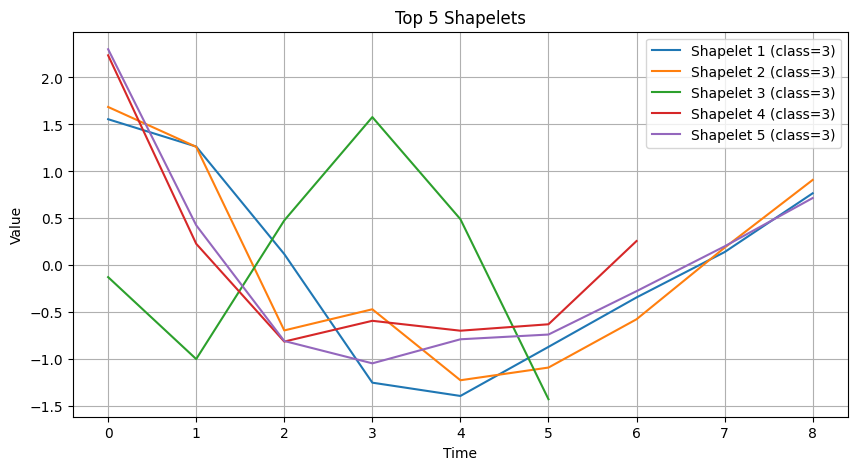

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, s in enumerate(shapelets[:5]):
    values = s[-1]
    sid = s[2]
    label = y_train[sid]
    ax.plot(values, label=f"Shapelet {i+1} (class={label})")
    
ax.legend()
ax.set_title("Top 5 Shapelets")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
plt.grid(True)
plt.show()


In [59]:
from collections import Counter
import numpy as np

shapelets = getattr(clf._transformer, "shapelets", getattr(clf._transformer, "shapelets_", None))
assert shapelets is not None, "Il trasformatore non espone shapelets"

cls_counts = Counter(int(y_train[s[2]]) for s in shapelets)  # s[2] = series_id
print("Shapelet per classe:", dict(cls_counts))


Shapelet per classe: {3: 646, 2: 161}


In [60]:
rf = RandomForestClassifier(
    n_estimators=300, 
    class_weight="balanced", 
    random_state=42
)
clf_balanced = ShapeletTransformClassifier(estimator=rf, random_state=42)
clf_balanced.fit(X_train, y_train)
print(classification_report(y_test, clf_balanced.predict(X_test)))


              precision    recall  f1-score   support

           0       0.53      0.60      0.56        75
           1       0.50      0.18      0.26        28
           2       0.50      0.79      0.61        78
           3       0.38      0.07      0.11        46

    accuracy                           0.51       227
   macro avg       0.48      0.41      0.39       227
weighted avg       0.48      0.51      0.45       227



In [61]:
from collections import Counter
import numpy as np

shapelets = getattr(clf_balanced._transformer, "shapelets")

cls_counts = Counter(int(y_train[s[2]]) for s in shapelets)  # s[2] = series_id
print("Shapelet per classe:", dict(cls_counts))


Shapelet per classe: {3: 646, 2: 161}
